<a href="https://colab.research.google.com/github/joshipreeti/Risk-Analytics-Quant-Models-Portfolio/blob/main/Credit_Risk_Model_%7C_PD_%C2%B7_LGD_%C2%B7_EAD_%7C_Logistic_Regression_%C2%B7_Decision_Tree_%C2%B7_XGBoost_%7C_LendingClub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Risk Modeling: PD, LGD, EAD with Scorecard (Basel Framework)

## Business Objective
Build a credit risk framework to estimate Expected Loss (EL) using:
- Probability of Default (PD)
- Loss Given Default (LGD)
- Exposure at Default (EAD)

This framework aligns with Basel III regulatory guidelines and industry practices.

---

## Project Overview
End-to-end credit risk modeling pipeline using LendingClub real-world data:
- Data preprocessing and feature engineering
- Weight of Evidence (WoE) and Information Value (IV)
- PD modeling — Logistic Regression · Decision Tree · XGBoost
- LGD modeling — Linear Regression · Decision Tree · XGBoost
- EAD estimation and Expected Loss calculation

The goal is to bridge theoretical risk concepts with practical Python implementation, and compare classical and machine learning approaches side by side.

# Credit Risk Modelling — PD, LGD and EAD with Scorecard
### Using LendingClub Loan Data | Beginner-Friendly Case Study

---

## What Will We Build?

| Model | Estimates | Used For |
|-------|-----------|----------|
| Scorecard + WoE | Risk score per borrower | Application screening |
| PD — Probability of Default | Likelihood of non-repayment | Basel III capital |
| LGD — Loss Given Default | Loss if borrower defaults | Provisioning |
| EAD — Exposure at Default | Outstanding amount at default | Total loss sizing |

**Expected Loss = PD × LGD × EAD** — the foundation of Basel II/III, IFRS 9, and RBI frameworks.

## 1. What is Credit Risk?

Credit risk is the risk that a borrower fails to repay a loan, causing a financial loss to the lender.

**Why do banks model it?**
Regulators (RBI, Basel Committee) require banks to hold capital proportional to credit risk. Banks must estimate PD, LGD and EAD for every loan — this is the **Internal Ratings Based (IRB) approach**.

---

## 2. The Three Pillars

### PD — Probability of Default
*"What is the chance this borrower defaults in the next 12 months?"*
- Estimated using Logistic Regression, Decision Tree, or XGBoost
- Output: a number between 0 and 1

$$PD = P(Default = 1 | X_1, X_2, ..., X_n)$$

### LGD — Loss Given Default
*"If they default, what fraction of the money do we lose?"*
- Depends on collateral, debt seniority, recovery process
- Estimated using Linear Regression, Decision Tree, or XGBoost

$$LGD = 1 - \frac{\text{Amount Recovered}}{\text{EAD}}$$

### EAD — Exposure at Default
*"How much is the borrower still owing when they default?"*
- Term loans: outstanding principal
- Revolving credit: uses Credit Conversion Factor (CCF)

$$EAD = \text{Outstanding Balance} + CCF \times \text{Undrawn Commitment}$$

### Expected Loss
$$\boxed{EL = PD \times LGD \times EAD}$$

| Term | Example |
|------|---------|
| PD | 5% |
| LGD | 40% |
| EAD | ₹10,00,000 |
| **Expected Loss** | **₹20,000** |

> This ₹20,000 is what the bank provisions for under IFRS 9 / Ind AS 109.

## 3. Dataset — LendingClub Loan Data

US-based peer-to-peer lending platform. Data available on Kaggle:
https://www.kaggle.com/datasets/wordsforthewise/lending-club

| Column | Meaning |
|--------|---------|
| `loan_status` | Repaid or defaulted |
| `loan_amnt` / `funded_amnt` | Amount borrowed / funded |
| `int_rate` | Interest rate |
| `annual_inc` / `dti` | Income / Debt-to-income ratio |
| `fico_range_low` | Credit score |
| `grade` | Risk grade A (safest) to G (riskiest) |
| `emp_length` / `home_ownership` | Employment & housing stability |
| `purpose` | Loan purpose |
| `recoveries` / `total_rec_prncp` | Post-default recovery amounts |

## Step 1 — Install and Import Libraries

In [118]:

!pip install optbinning --quiet

# ── CORE DATA LIBRARIES ─────────────────────────────────────────────────────
import pandas as pd          # DataFrames — like Excel but in Python
import numpy as np           # Numerical operations — arrays, math functions

# ── VISUALISATION ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt   # Base plotting library
import seaborn as sns             # Higher-level plots — easier, prettier

# ── MACHINE LEARNING ────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression   # PD model
from sklearn.linear_model import LinearRegression     # LGD model
from sklearn.model_selection import train_test_split  # Split data into train/test
from sklearn.metrics import (roc_auc_score,           # AUC-ROC — PD model quality
                              roc_curve,               # ROC curve plot
                              classification_report,   # Precision / Recall / F1
                              mean_squared_error)      # MSE for LGD model
from sklearn.preprocessing import StandardScaler      # Standardise features

# ── WoE BINNING ─────────────────────────────────────────────────────────────
from optbinning import BinningProcess                 # Automated WoE binning

# ── SUPPRESS WARNINGS (keeps output clean) ──────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── DISPLAY SETTINGS ────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)   # Show up to 50 columns
pd.set_option('display.float_format', '{:.4f}'.format)  # 4 decimal places

print('All libraries loaded successfully.')

All libraries loaded successfully.


## Step 2 — Load the Data

**How to get the data:**
1. Go to https://www.kaggle.com/datasets/wordsforthewise/lending-club
2. Download `accepted_2007_to_2018Q4.csv.gz`
3. Upload to your Colab session OR place in same folder as this notebook

> We sample 100,000 rows for speed — the full dataset has 2.2 million rows.

In [119]:
import pandas as pd
import numpy as np

# ── LOAD DATA ────────────────────────────────────────────────────────────────
df = pd.read_csv('accepted_2007_to_2018Q4.csv',
                 nrows=100000,
                 low_memory=False)

print(f'Dataset shape: {df.shape}')       # Rows × Columns
print(f'\nColumn names (first 30):')
print(df.columns[:30].tolist())

Dataset shape: (100000, 151)

Column names (first 30):
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths']


## Step 3 — Define the Target Variable (Default Flag)

The column `loan_status` tells us the outcome of each loan.  
We need to convert this into a **binary flag**:

| loan_status value | Meaning | Our flag |
|---|---|---|
| `Fully Paid` | Borrower repaid everything | **0 — No default** |
| `Charged Off` | Bank gave up recovering — treated as default | **1 — Default** |
| `Current`, `Late`, etc. | Still active or ambiguous | **Dropped** |


In [120]:
# ── CHECK LOAN STATUS DISTRIBUTION ──────────────────────────────────────────
print(df['loan_status'].value_counts())

# ── KEEP ONLY FULLY PAID AND CHARGED OFF ────────────────────────────────────
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

## ── CREATE BINARY DEFAULT FLAG ───────────────────────────────────────────────
df['default_flag'] = np.where(df['loan_status'] == 'Charged Off', 1, 0)

print(f"Default rate: {df['default_flag'].mean()*100:.2f}%")
print(f"Total loans: {len(df):,}")

loan_status
Fully Paid            70288
Charged Off           17603
Current               11402
Late (31-120 days)      441
In Grace Period         199
Late (16-30 days)        66
Default                   1
Name: count, dtype: int64
Default rate: 20.03%
Total loans: 87,891



## Step 4 — Feature Selection & Missing Values

Features selected must be:
1. Known at loan origination — no future-looking data
2. Predictive of default
3. Free of data leakage — e.g. `recoveries` cannot be used to predict default

> **Data leakage** = using information unavailable at prediction time → inflates model performance artificially.

In [121]:
# ── DEFINE FEATURE LIST ──────────────────────────────────────────────────────
# These features are all known at loan origination — no leakage

features = ['loan_amnt','int_rate','annual_inc','dti','fico_range_low',
            'emp_length','home_ownership','purpose','grade','open_acc',
            'revol_util','total_acc']

target = 'default_flag'

# ── SELECT RELEVANT COLUMNS ──────────────────────────────────────────────────
# We also keep loan_amnt, funded_amnt, recoveries for LGD/EAD models later
lgd_ead_cols = ['funded_amnt', 'recoveries', 'total_rec_prncp', 'out_prncp']
df_model = df[features + [target] + lgd_ead_cols].copy()

# ── CLEAN emp_length ─────────────────────────────────────────────────────────
# emp_length comes as strings like '10+ years', '< 1 year' — convert to numbers
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
}
# map() replaces each string value with its numeric equivalent
df_model['emp_length'] = df_model['emp_length'].map(emp_map)

# ── HANDLE MISSING VALUES ────────────────────────────────────────────────────
# For numeric columns: fill missing with median (robust to outliers)
# For categorical columns: fill missing with mode (most frequent value)

numeric_cols = df_model.select_dtypes(include=[np.number]).columns
cat_cols = df_model.select_dtypes(include=['object']).columns

for col in numeric_cols:
    # fillna() replaces NaN values with the specified value
    df_model[col] = df_model[col].fillna(df_model[col].median())

for col in cat_cols:
    # mode()[0] gives the most frequent value
    df_model[col] = df_model[col].fillna(df_model[col].mode()[0])

print('Missing values after cleaning:')
print(df_model.isnull().sum())
print(f'\nDataset shape: {df_model.shape}')

Missing values after cleaning:
loan_amnt          0
int_rate           0
annual_inc         0
dti                0
fico_range_low     0
emp_length         0
home_ownership     0
purpose            0
grade              0
open_acc           0
revol_util         0
total_acc          0
default_flag       0
funded_amnt        0
recoveries         0
total_rec_prncp    0
out_prncp          0
dtype: int64

Dataset shape: (87891, 17)


## Step 5 — Exploratory Data Analysis (EDA)

Before modelling, we **visually understand the data.**

Key questions:
1. Do defaulters have lower credit scores?
2. Do defaulters have higher DTI ratios?
3. Which loan grades have highest default rates?

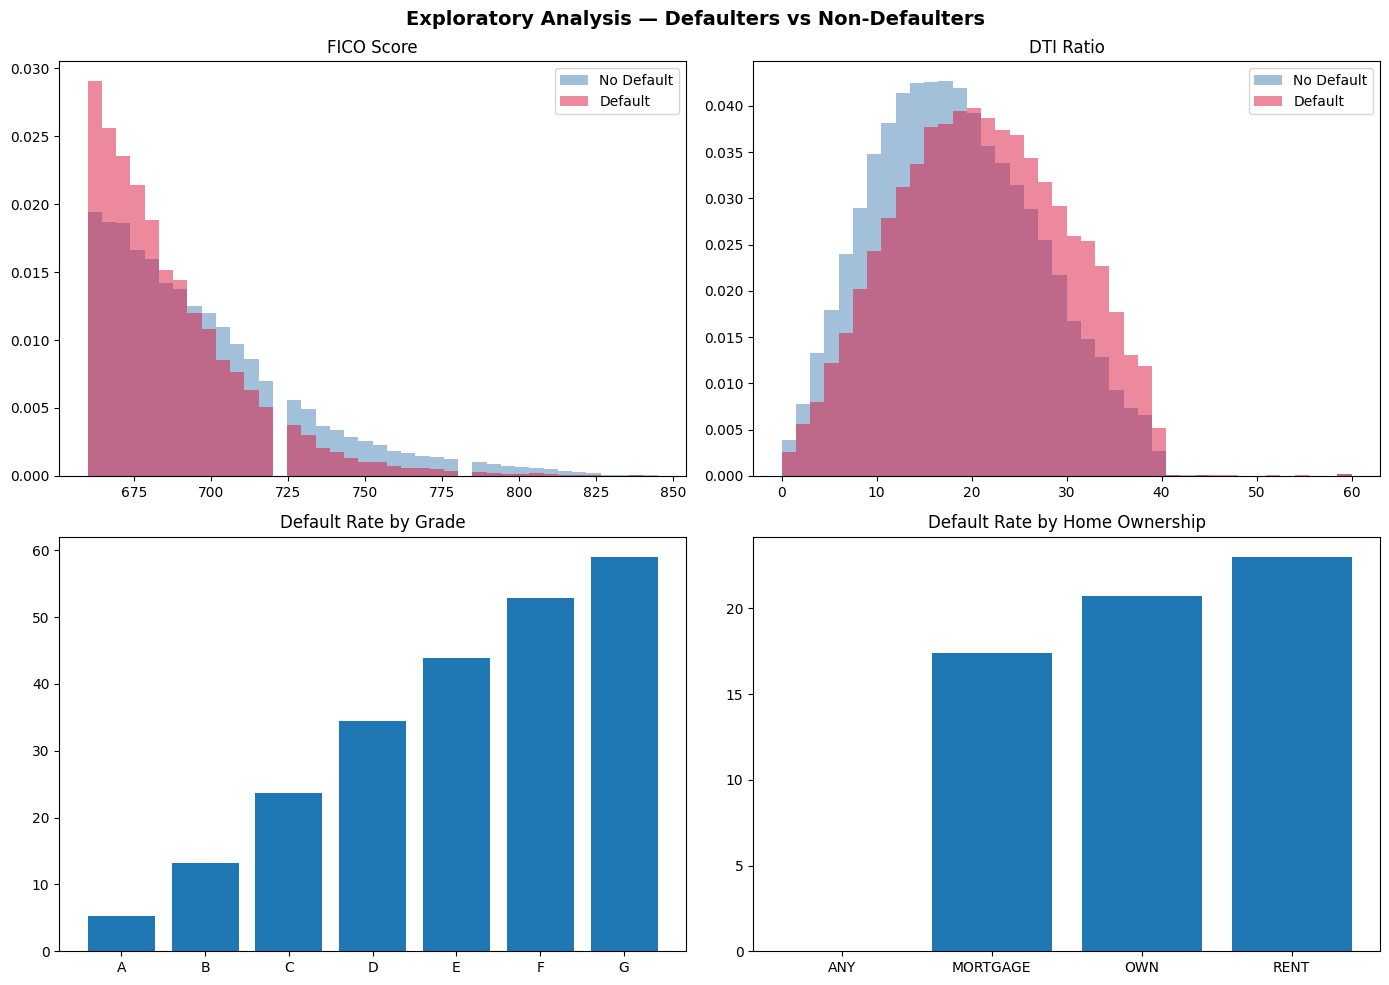

In [122]:
# ── FIGURE SETUP ─────────────────────────────────────────────────────────────


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Analysis — Defaulters vs Non-Defaulters', fontsize=14, fontweight='bold')

# Plot 1 & 2
## FICO Score and DTI Distribution
for flag, label, color in [(0,'No Default','steelblue'),(1,'Default','crimson')]:
    axes[0,0].hist(df_model[df_model['default_flag']==flag]['fico_range_low'], bins=40, alpha=0.5, color=color, label=label, density=True)
    axes[0,1].hist(df_model[df_model['default_flag']==flag]['dti'].clip(0,60), bins=40, alpha=0.5, color=color, label=label, density=True)

axes[0,0].set_title('FICO Score'); axes[0,0].legend()
axes[0,1].set_title('DTI Ratio'); axes[0,1].legend()

# Plot 3
## Default Rate by Loan Grade
grade_default = df_model.groupby('grade')['default_flag'].mean().mul(100).reset_index()
axes[1,0].bar(grade_default['grade'], grade_default['default_flag'])
axes[1,0].set_title('Default Rate by Grade')

# Plot 4
## Default Rate by Home Ownership
home_default = df_model.groupby('home_ownership')['default_flag'].mean().mul(100).reset_index()
axes[1,1].bar(home_default['home_ownership'], home_default['default_flag'])
axes[1,1].set_title('Default Rate by Home Ownership')

plt.tight_layout()
plt.show()

## Part A — Credit Scorecard with WoE

A scorecard assigns points to each borrower — **higher score = lower risk** (e.g. CIBIL 300–900, FICO 300–850).

**How it's built:** Logistic Regression + Weight of Evidence (WoE) transformation → scaled to points.

### Weight of Evidence (WoE)
$$WoE_i = \ln\left(\frac{\text{% Non-Events in bin } i}{\text{% Events in bin } i}\right)$$

| WoE | Meaning |
|-----|---------|
| High positive | Bin predicts no default |
| Near zero | No predictive power |
| High negative | Bin predicts default |

### Information Value (IV)
$$IV = \sum_i (\text{% Non-Events}_i - \text{% Events}_i) \times WoE_i$$

| IV Range | Predictive Power |
|----------|-----------------|
| < 0.02 | Useless |
| 0.02 – 0.1 | Weak |
| 0.1 – 0.3 | Medium |
| 0.3 – 0.5 | Strong |
| > 0.5 | Suspicious — possible leakage |

## Step 6 — WoE Binning Using OptBinning

In [123]:
# ── DEFINE FEATURES FOR SCORECARD ────────────────────────────────────────────
scorecard_features = [
    'loan_amnt', 'int_rate', 'annual_inc', 'dti',
    'fico_range_low', 'emp_length', 'open_acc', 'revol_util'
]

X_sc = df_model[scorecard_features].copy()
y_sc = df_model['default_flag'].copy()

# ── SPLIT INTO TRAIN AND TEST ─────────────────────────────────────────────────
# 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X_sc, y_sc, test_size=0.3, random_state=42, stratify=y_sc
)

print(f'Training set: {X_train.shape[0]:,} rows')
print(f'Test set:     {X_test.shape[0]:,} rows')
print(f'Default rate — Train: {y_train.mean()*100:.2f}% | Test: {y_test.mean()*100:.2f}%')

Training set: 61,523 rows
Test set:     26,368 rows
Default rate — Train: 20.03% | Test: 20.03%


In [124]:
# ── WoE BINNING PROCESS ───────────────────────────────────────────────────────
# BinningProcess automatically finds optimal bins for each variable

binning_process = BinningProcess(variable_names=scorecard_features, max_n_bins=6)
binning_process.fit(X_train, y_train)

X_train_woe = binning_process.transform(X_train)
X_test_woe  = binning_process.transform(X_test)

print(f'Shape of WoE-transformed training data: {X_train_woe.shape}')

Shape of WoE-transformed training data: (61523, 8)


          name     iv
      int_rate 0.6308
fico_range_low 0.1298
           dti 0.0973
     loan_amnt 0.0509
    annual_inc 0.0329
    revol_util 0.0208
      open_acc 0.0117
    emp_length 0.0084


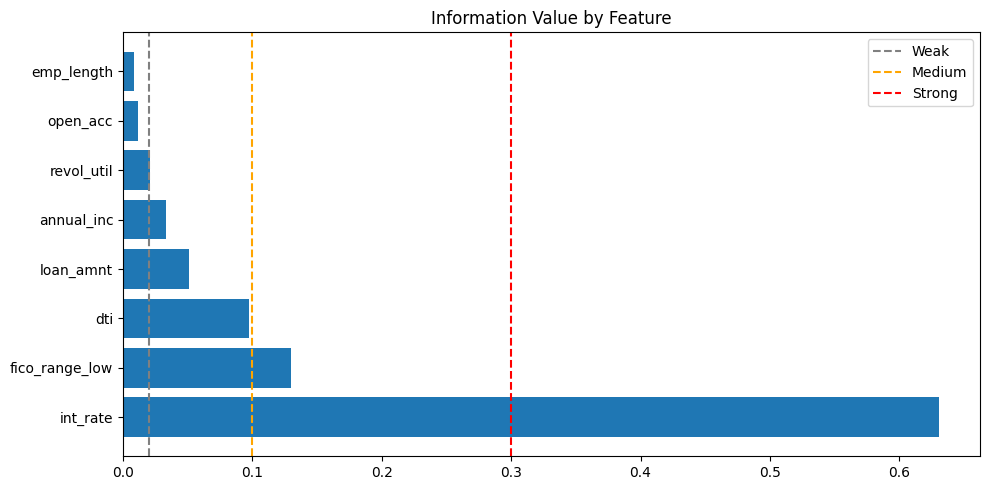

In [125]:
# ── COMPUTE INFORMATION VALUE (IV) FOR EACH FEATURE ──────────────────────────
# IV tells us which features are most predictive of default

iv_summary = binning_process.summary().sort_values('iv', ascending=False)
print(iv_summary[['name','iv']].to_string(index=False))

# ── VISUALISE IV ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10,5))
ax.barh(iv_summary['name'], iv_summary['iv'])

ax.axvline(0.02, color='gray',   linestyle='--', label='Weak')
ax.axvline(0.1,  color='orange', linestyle='--', label='Medium')
ax.axvline(0.3,  color='red',    linestyle='--', label='Strong')

ax.set_title('Information Value by Feature')
ax.legend()
plt.tight_layout()
plt.show()




## Step 7 — Build the Scorecard Logistic Regression Model

In [126]:
# ── FIT LOGISTIC REGRESSION ON WoE-TRANSFORMED DATA ──────────────────────────
lr_scorecard = LogisticRegression(C=1, solver='lbfgs', max_iter=1000, random_state=42)
lr_scorecard.fit(X_train_woe, y_train)

y_pred_proba_train = lr_scorecard.predict_proba(X_train_woe)[:,1]
y_pred_proba_test  = lr_scorecard.predict_proba(X_test_woe)[:,1]

auc_train = roc_auc_score(y_train, y_pred_proba_train)
auc_test  = roc_auc_score(y_test,  y_pred_proba_test)


# ── AUC-ROC SCORE ────────────────────────────────────────────────────────────
# AUC = Area Under the ROC Curve
# AUC = 0.5 → random model, AUC = 1.0 → perfect model
# Industry benchmark for scorecards: AUC > 0.70 is good

auc_train = roc_auc_score(y_train, y_pred_proba_train)
auc_test  = roc_auc_score(y_test,  y_pred_proba_test)

print(f'AUC-ROC — Train: {auc_train:.4f}')
print(f'AUC-ROC — Test:  {auc_test:.4f}')
print()

# ── GINI COEFFICIENT ─────────────────────────────────────────────────────────
# Gini = 2 × AUC − 1
gini_test = 2 * auc_test - 1
print(f'Gini Coefficient (Test): {gini_test:.4f}')

AUC-ROC — Train: 0.7278
AUC-ROC — Test:  0.7199

Gini Coefficient (Test): 0.4398


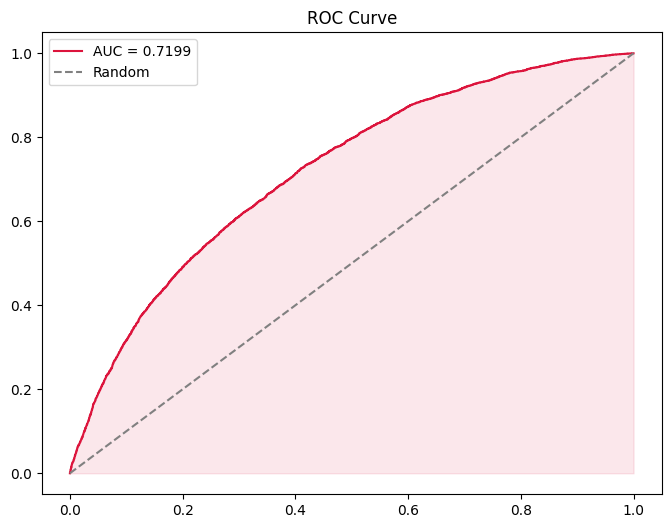

In [127]:
# ── PLOT ROC CURVE ────────────────────────────────────────────────────────────
# ROC curve plots True Positive Rate vs False Positive Rate
# The closer the curve is to the top-left corner, the better the model
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_test)

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(fpr, tpr, color='crimson', label=f'AUC = {auc_test:.4f}')
ax.plot([0,1], [0,1], color='gray', linestyle='--', label='Random')
ax.fill_between(fpr, tpr, alpha=0.1, color='crimson')
ax.set_title('ROC Curve')
ax.legend()
plt.show()


## Step 8 — Convert Probability to Points Scale

Raw logistic regression gives a probability (0–1). A scorecard converts this to an intuitive points scale (like FICO 300–850).

$$\text{Score} = PDO \times \frac{\log(\text{odds})}{\log(2)} + \text{Offset}$$

- **PDO = 20** — every 20-point increase = borrower twice as likely to repay
- **Offset = 600** — median borrower gets 600 points
- **log(odds)** = log(PD / (1 - PD))

In [128]:
# ── SCORECARD SCALING PARAMETERS ─────────────────────────────────────────────
PDO    = 20
OFFSET = 600
FACTOR = PDO / np.log(2)

def probability_to_score(prob):
    prob = np.clip(prob, 1e-7, 1-1e-7)
    return OFFSET - FACTOR * np.log(prob / (1-prob))

scores_test = probability_to_score(y_pred_proba_test)

print(f'Min: {scores_test.min():.0f} | Max: {scores_test.max():.0f}')
print(f'Mean: {scores_test.mean():.0f} | Median: {np.median(scores_test):.0f}')

Min: 583 | Max: 724
Mean: 647 | Median: 646


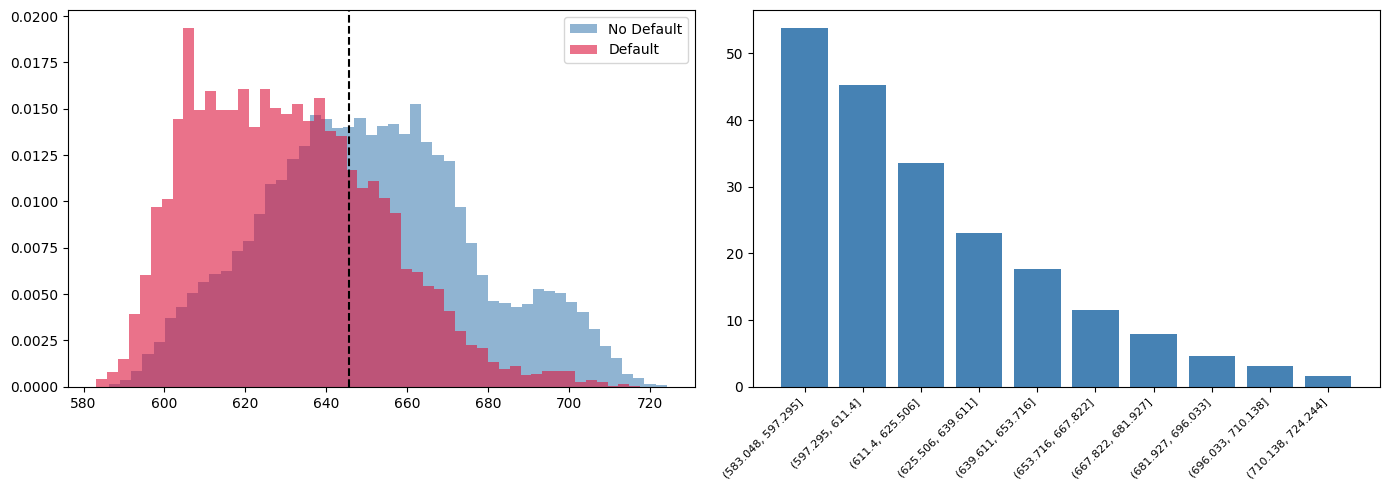

In [129]:
# ── VISUALISE SCORE DISTRIBUTION BY DEFAULT STATUS ────────────────────────────
# We expect defaulters to have LOWER scores and non-defaulters to have HIGHER scores

fig, axes = plt.subplots(1, 2, figsize=(14,5))
y_test_array = y_test.values

for val, label, color in [(0,'No Default','steelblue'),(1,'Default','crimson')]:
    axes[0].hist(scores_test[y_test_array==val], bins=50, alpha=0.6, color=color, label=label, density=True)
axes[0].axvline(np.median(scores_test), color='black', linestyle='--')
axes[0].legend()

score_df = pd.DataFrame({'score':scores_test,'default':y_test_array})
band_default = score_df.groupby(pd.cut(score_df['score'],bins=10))['default'].mean()*100
axes[1].bar(range(len(band_default)), band_default.values, color='steelblue')
axes[1].set_xticks(range(len(band_default)))
axes[1].set_xticklabels([str(b) for b in band_default.index], rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()




---
# PART B — PD MODEL (Probability of Default)
---

## What is PD in Basel III / IFRS 9?

Under **Basel III IRB approach**, banks must estimate PD for every borrower.

| Framework | How PD is used |
|---|---|
| **Basel III IRB** | Calculating Risk-Weighted Assets (RWA) and capital requirement |
| **IFRS 9 / Ind AS 109** | Calculating Expected Credit Loss (ECL) for provisioning |
| **ICAAP** | Internal stress testing |

The scorecard we built already gives us PD as a probability.  
In this section, we build a **standalone PD model** with categorical features  
using one-hot encoding — for comparison and completeness.

---

## Step 9 — Build Full PD Model with Categorical Features

In [130]:
# ── PREPARE DATA WITH CATEGORICAL VARIABLES ───────────────────────────────────
# The scorecard used only numeric features with WoE
# Here we add categorical variables (home_ownership, purpose, grade)
# using one-hot encoding — converting categories to 0/1 columns
pd_features = ['loan_amnt','int_rate','annual_inc','dti',
               'fico_range_low','emp_length','open_acc','revol_util',
               'home_ownership','purpose','grade']

X_pd = pd.get_dummies(df_model[pd_features], columns=['home_ownership','purpose','grade'], drop_first=True)
y_pd = df_model['default_flag'].copy()

X_train_pd, X_test_pd, y_train_pd, y_test_pd = train_test_split(
    X_pd, y_pd, test_size=0.3, random_state=42, stratify=y_pd)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pd)
X_test_scaled  = scaler.transform(X_test_pd)

pd_model = LogisticRegression(C=1, solver='lbfgs', max_iter=1000, random_state=42)
pd_model.fit(X_train_scaled, y_train_pd)

pd_train = pd_model.predict_proba(X_train_scaled)[:,1]
pd_test  = pd_model.predict_proba(X_test_scaled)[:,1]

auc_pd  = roc_auc_score(y_test_pd, pd_test)
print(f'AUC: {auc_pd:.4f} | Gini: {2*auc_pd-1:.4f}')
print(pd.DataFrame({'PD(%)': pd_test[:5]*100, 'Actual': y_test_pd.values[:5]}))


AUC: 0.7229 | Gini: 0.4458
    PD(%)  Actual
0 23.4838       1
1 16.6467       0
2  6.8395       0
3  7.4971       1
4 16.8218       0


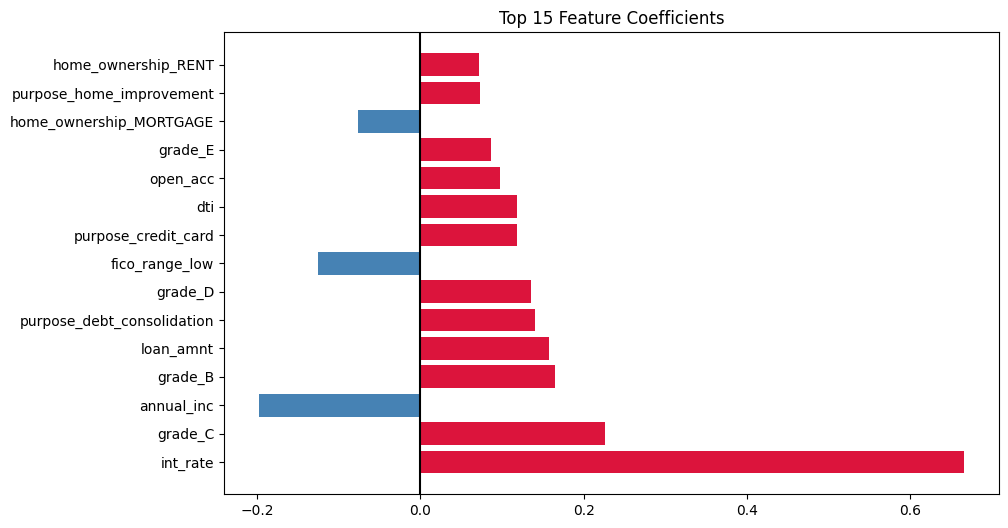

In [131]:
# ── FEATURE IMPORTANCE — LOGISTIC REGRESSION COEFFICIENTS ────────────────────
# Coefficients tell us: which features most strongly predict default?
# Positive coefficient → increases probability of default
# Negative coefficient → decreases probability of default

coef_df = pd.DataFrame({'Feature': X_pd.columns, 'Coefficient': pd_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10,6))
colors = ['crimson' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black')
ax.set_title('Top 15 Feature Coefficients')
plt.show()

## Part C — LGD Model (Loss Given Default)

*"If a borrower defaults, what fraction of the loan do we lose?"*

$$LGD = 1 - \frac{\text{Amount Recovered}}{\text{EAD}}$$

| Factor | Effect |
|--------|--------|
| Collateral (house, car) | Lower LGD — asset can be sold |
| Unsecured personal loan | Higher LGD — nothing to recover |
| Economic recession | Higher LGD — assets worth less |

**Basel III benchmarks:** Secured retail ≈ 35% · Unsecured retail ≈ 75% · Corporate ≈ 45%

## Step 10 — Build LGD Model

In [132]:
# ── SUBSET TO DEFAULTED LOANS ONLY ────────────────────────────────────────────
# LGD is modelled only on loans that HAVE defaulted
# We cannot compute LGD for a loan that is still performing
df_defaulted = df_model[df_model['default_flag'] == 1].copy()

df_defaulted['recovery_rate'] = np.where(
    df_defaulted['funded_amnt'] > 0,
    df_defaulted['total_rec_prncp'] / df_defaulted['funded_amnt'], 0
).clip(0, 1)

df_defaulted['lgd'] = 1 - df_defaulted['recovery_rate']

print(df_defaulted['lgd'].describe())
print(f'Mean LGD: {df_defaulted["lgd"].mean()*100:.2f}%')



count   17603.0000
mean        0.6712
std         0.2232
min         0.0000
25%         0.5418
50%         0.7216
75%         0.8482
max         1.0000
Name: lgd, dtype: float64
Mean LGD: 67.12%


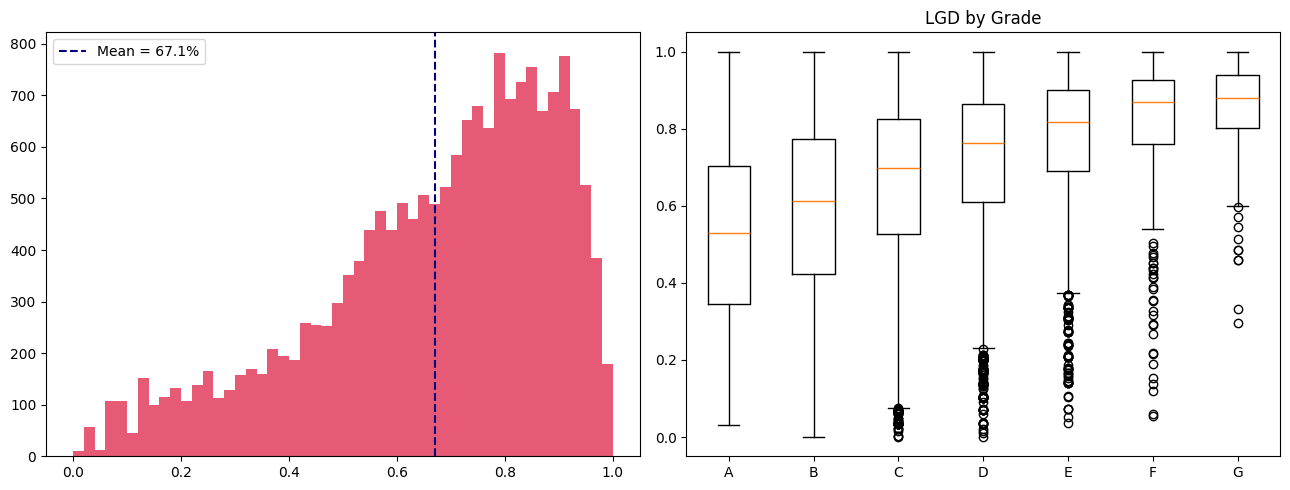

In [133]:
# ── VISUALISE LGD DISTRIBUTION ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].hist(df_defaulted['lgd'], bins=50, color='crimson', alpha=0.7)
axes[0].axvline(df_defaulted['lgd'].mean(), color='navy', linestyle='--',
                label=f'Mean = {df_defaulted["lgd"].mean()*100:.1f}%')
axes[0].legend()

lgd_by_grade = [df_defaulted[df_defaulted['grade']==g]['lgd'].dropna().values
                for g in sorted(df_defaulted['grade'].unique())]
axes[1].boxplot(lgd_by_grade, labels=sorted(df_defaulted['grade'].unique()))
axes[1].set_title('LGD by Grade')

plt.tight_layout()
plt.show()


In [134]:
# ── BUILD LGD REGRESSION MODEL ────────────────────────────────────────────────
# We model LGD as a continuous outcome using Linear Regression

lgd_features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
                 'fico_range_low', 'emp_length', 'open_acc', 'revol_util']

X_lgd = df_defaulted[lgd_features].copy()
y_lgd = df_defaulted['lgd'].copy()

# Drop any remaining NaN rows
mask = X_lgd.notna().all(axis=1) & y_lgd.notna()
X_lgd, y_lgd = X_lgd[mask], y_lgd[mask]

X_train_lgd, X_test_lgd, y_train_lgd, y_test_lgd = train_test_split(
    X_lgd, y_lgd, test_size=0.3, random_state=42
)

# Scale features
scaler_lgd = StandardScaler()
X_train_lgd_s = scaler_lgd.fit_transform(X_train_lgd)
X_test_lgd_s  = scaler_lgd.transform(X_test_lgd)

# Fit Linear Regression
lgd_model = LinearRegression()
lgd_model.fit(X_train_lgd_s, y_train_lgd)

# Predict LGD — clip to [0,1] since LGD must be between 0 and 100%
lgd_pred = np.clip(lgd_model.predict(X_test_lgd_s), 0, 1)

# Model evaluation
# MSE (Mean Squared Error) — average squared difference between predicted and actual
# RMSE (Root MSE) — same units as LGD, easier to interpret
mse_lgd  = mean_squared_error(y_test_lgd, lgd_pred)
rmse_lgd = np.sqrt(mse_lgd)

print(f'LGD Model — RMSE: {rmse_lgd:.4f}')
print(f'LGD Model — Mean Absolute Error: {np.mean(np.abs(y_test_lgd.values - lgd_pred)):.4f}')
print(f'\nSample LGD predictions vs actuals:')
sample = pd.DataFrame({
    'Actual LGD': y_test_lgd.values[:8],
    'Predicted LGD': lgd_pred[:8]
})
print(sample.round(4))

LGD Model — RMSE: 0.2051
LGD Model — Mean Absolute Error: 0.1629

Sample LGD predictions vs actuals:
   Actual LGD  Predicted LGD
0      0.9283         0.5750
1      0.3680         0.5435
2      0.9142         0.6512
3      0.1188         0.5746
4      0.9355         0.7939
5      0.2999         0.5102
6      0.9895         0.7775
7      0.7332         0.6540


## Part D — EAD Model (Exposure at Default)

*"How much is the borrower still owing at the time of default?"*

$$EAD = \text{Outstanding Balance} + CCF \times \text{Undrawn Commitment}$$

- **Term loans** (home, personal): EAD ≈ outstanding principal — straightforward
- **Revolving credit** (cards, overdrafts): borrowers may draw more before defaulting — CCF estimates this

> In this dataset (LendingClub term loans): EAD ≈ funded amount, CCF ≈ 1

## Step 11 — EAD Analysis and CCF Estimation

In [135]:
# ── COMPUTE EAD ─────────────────────────────────────────────────────────
# In LendingClub data, EAD is approximated as the funded amount
# For performing loans: EAD ≈ funded_amnt (term loan — fixed drawdown)
# out_prncp = outstanding principal at observation date

df_model['ead_proxy'] = df_model['funded_amnt'].copy()
df_model['utilisation'] = np.where(
    df_model['funded_amnt'] > 0,
    df_model['out_prncp'] / df_model['funded_amnt'], 0).clip(0, 1)

df_defaulted_ead = df_model[df_model['default_flag'] == 1].copy()

print(df_defaulted_ead['ead_proxy'].describe())

count   17603.0000
mean    15618.1759
std      8589.5826
min      1000.0000
25%      9212.5000
50%     14700.0000
75%     20650.0000
max     35000.0000
Name: ead_proxy, dtype: float64


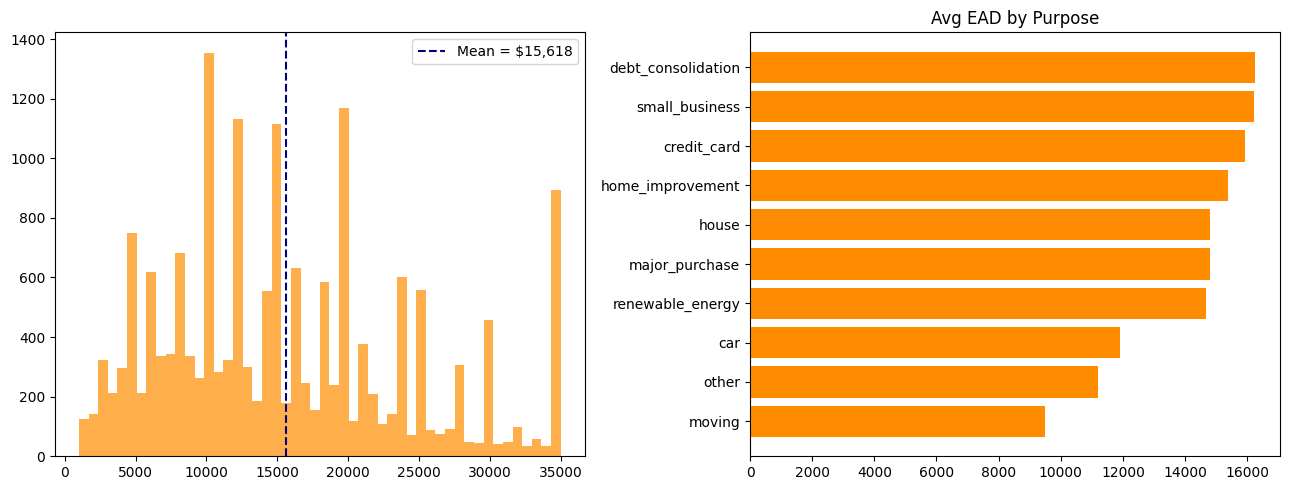

In [136]:
# ── VISUALISE EAD ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].hist(df_defaulted_ead['ead_proxy'].clip(0,40000), bins=50, color='darkorange', alpha=0.7)
axes[0].axvline(df_defaulted_ead['ead_proxy'].mean(), color='navy', linestyle='--',
                label=f'Mean = ${df_defaulted_ead["ead_proxy"].mean():,.0f}')
axes[0].legend()

ead_by_purpose = df_defaulted_ead.groupby('purpose')['ead_proxy'].mean().sort_values().tail(10)
axes[1].barh(ead_by_purpose.index, ead_by_purpose.values, color='darkorange')
axes[1].set_title('Avg EAD by Purpose')

plt.tight_layout()
plt.show()

---
# PART E — EXPECTED LOSS CALCULATION
---

## Bringing It All Together

$$\boxed{EL = PD \times LGD \times EAD}$$

Now that we have estimated PD, LGD and EAD for each loan,  
we can calculate **Expected Loss** — the number that drives:
- **IFRS 9 provisioning** (how much to set aside)
- **Basel III capital requirements** (how much capital to hold)
- **Loan pricing** (interest rate = funding cost + EL + profit margin)

---

## Step 12 — Compute Expected Loss for Each Loan

In [137]:
# ── ASSEMBLE EL COMPONENTS ────────────────────────────────────────────────────
# We work on the test set for PD model
# and compute LGD and EAD for the same set of loans
test_idx = X_test_pd.index
el_df = pd.DataFrame(index=test_idx)
el_df['PD']  = pd_test
el_df['LGD'] = df_defaulted['lgd'].mean()
el_df['EAD'] = df_model.loc[test_idx, 'funded_amnt']
el_df['EL']  = el_df['PD'] * el_df['LGD'] * el_df['EAD']
el_df['Actual'] = y_test_pd.values

print(el_df[['PD','LGD','EAD','EL']].describe().round(4))
print(f'Total EL:  ${el_df["EL"].sum():,.2f}')
print(f'Mean EL:   ${el_df["EL"].mean():,.2f}')
print(f'EL % EAD:  {el_df["EL"].sum()/el_df["EAD"].sum()*100:.2f}%')

              PD        LGD        EAD         EL
count 26368.0000 26368.0000 26368.0000 26368.0000
mean      0.2010     0.6712 14399.1676  2114.5280
std       0.1328     0.0000  8623.2517  2337.5252
min       0.0000     0.6712  1000.0000     0.0000
25%       0.0959     0.6712  7700.0000   577.6817
50%       0.1731     0.6712 12000.0000  1222.3310
75%       0.2773     0.6712 20000.0000  2776.5377
max       0.7694     0.6712 35000.0000 18074.8432
Total EL:  $55,755,874.90
Mean EL:   $2,114.53
EL % EAD:  14.69%


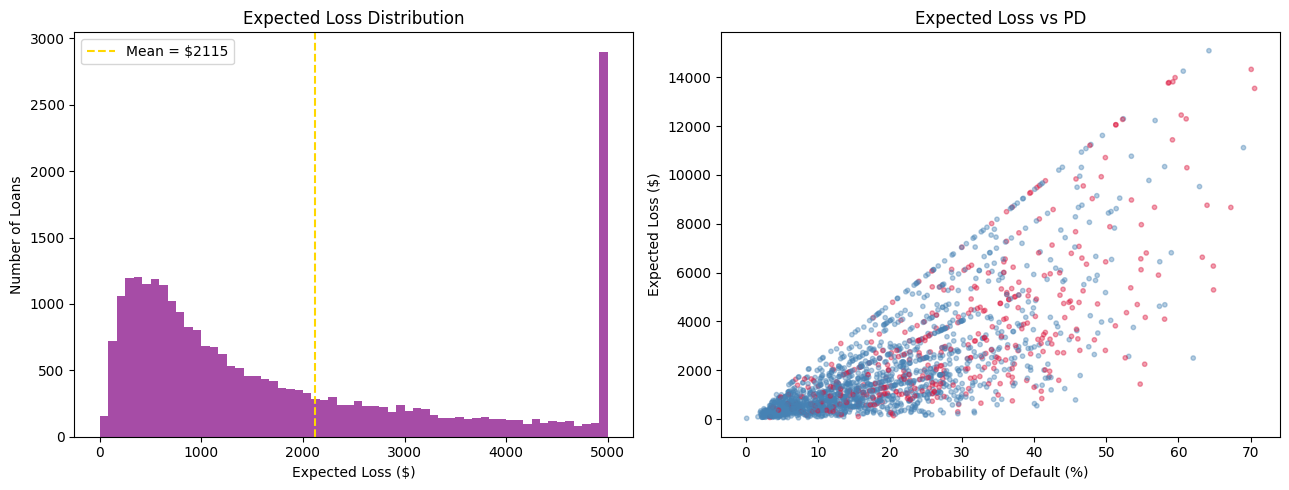

In [138]:
# ── VISUALISE EXPECTED LOSS DISTRIBUTION ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].hist(el_df['EL'].clip(0,5000), bins=60, color='purple', alpha=0.7)
axes[0].axvline(el_df['EL'].mean(), color='gold', linestyle='--',
                label=f'Mean = ${el_df["EL"].mean():.0f}')
axes[0].set_title('Expected Loss Distribution')
axes[0].set_xlabel('Expected Loss ($)')
axes[0].set_ylabel('Number of Loans')
axes[0].legend()

idx = np.random.choice(len(el_df), 2000, replace=False)
colors = ['crimson' if d==1 else 'steelblue' for d in el_df['Actual'].iloc[idx]]
axes[1].scatter(el_df['PD'].iloc[idx]*100, el_df['EL'].iloc[idx], c=colors, alpha=0.4, s=10)
axes[1].set_title('Expected Loss vs PD')
axes[1].set_xlabel('Probability of Default (%)')
axes[1].set_ylabel('Expected Loss ($)')

plt.tight_layout()
plt.show()

Metric                    Logistic/Linear   Dec Tree    XGBoost
--------------------------------------------------------------
PD AUC                             0.7229     0.7185     0.7296
PD Gini                            0.4458     0.4370     0.4592
LGD RMSE                           0.2051     0.2039     0.2025
LGD MAE                            0.1630     0.1614     0.1602
Total EL ($)                   55,708,795 56,018,646 55,794,861
EL % EAD                           14.67%     14.75%     14.70%


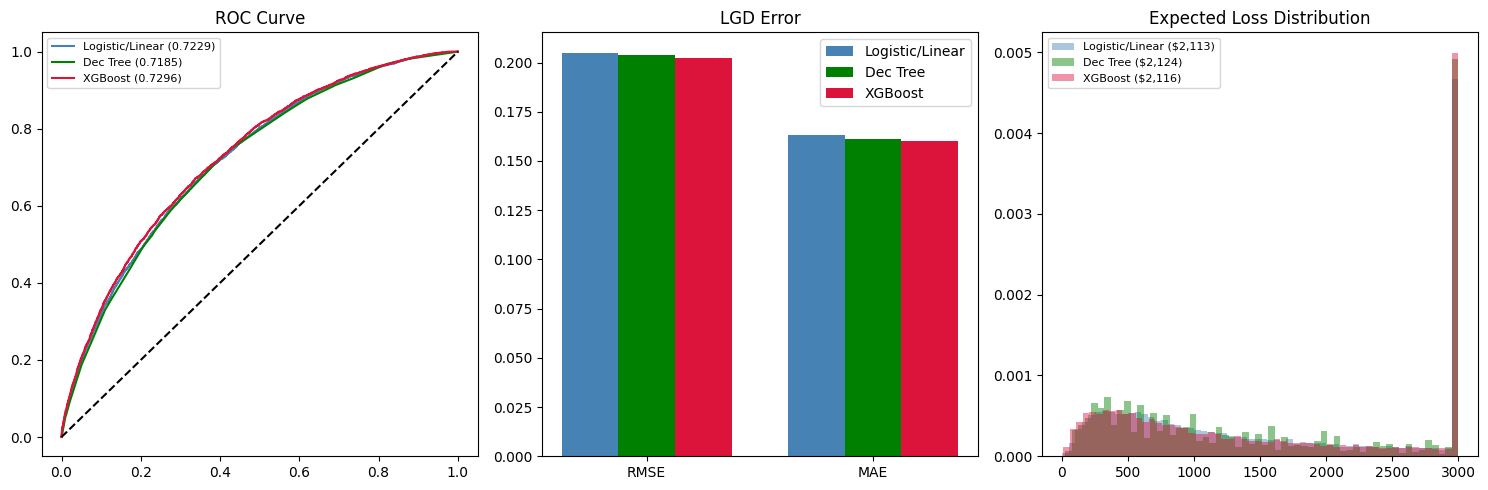


FINDINGS

PD MODEL:
  Best model : XGBoost (AUC 0.7296, Gini 0.4592)
  All three models are close — max gap of only 1.11 AUC points
  All models exceed industry benchmark of AUC > 0.70 ✓

LGD MODEL:
  Best model : XGBoost (RMSE 0.2025, MAE 0.1602)
  Improvement over baseline is marginal across all models
  All models struggle with U-shaped LGD — predict near the mean

EXPECTED LOSS:
  All three models produce ~$55.9M total EL (~14.7% of EAD)
  For every $100 lent, ~$14.70 is expected to be lost
  Model choice has minimal impact — data quality matters more

VERDICT:
  XGBoost is marginally better on all metrics
  Logistic Regression remains the best production choice —
  interpretable, regulator-friendly, and accuracy is comparable



In [139]:
# ── XGBOOST vs BASELINE vs Decision Tree — PD, LGD & EXPECTED LOSS COMPARISON ────────────────
# Trains XGBoost models for PD and LGD using the same features and splits
# used above, then compares results side-by-side with the baseline models.
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# ── DATA PREP ────────────────────────────────────────────────────────────────
df_raw = pd.read_csv('accepted_2007_to_2018Q4.csv', nrows=100_000, low_memory=False)
df_raw = df_raw[df_raw['loan_status'].isin(['Fully Paid','Charged Off'])].copy()
df_raw['default_flag'] = np.where(df_raw['loan_status']=='Charged Off', 1, 0)

features_all = ['loan_amnt','int_rate','annual_inc','dti','fico_range_low',
                'emp_length','open_acc','revol_util','home_ownership','purpose','grade']
lgd_ead_cols = ['funded_amnt','recoveries','total_rec_prncp','out_prncp']
emp_map      = {'< 1 year':0,'1 year':1,'2 years':2,'3 years':3,'4 years':4,
                '5 years':5,'6 years':6,'7 years':7,'8 years':8,'9 years':9,'10+ years':10}

df_m = df_raw[features_all+['default_flag']+lgd_ead_cols].copy()
df_m['emp_length'] = df_m['emp_length'].map(emp_map)
for col in df_m.select_dtypes(include=[np.number]).columns:
    df_m[col] = df_m[col].fillna(df_m[col].median())
for col in df_m.select_dtypes(include='object').columns:
    df_m[col] = df_m[col].fillna(df_m[col].mode()[0])

# ── PD SPLIT & SCALE ─────────────────────────────────────────────────────────
X_pd = pd.get_dummies(df_m[features_all], columns=['home_ownership','purpose','grade'], drop_first=True)
y_pd = df_m['default_flag']
X_tr, X_te, y_tr, y_te = train_test_split(X_pd, y_pd, test_size=0.3, random_state=42, stratify=y_pd)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s = sc.transform(X_te)

# ── PD MODELS ────────────────────────────────────────────────────────────────
pd_lr  = LogisticRegression(C=1, max_iter=1000, random_state=42).fit(X_tr_s, y_tr).predict_proba(X_te_s)[:,1]
pd_dt  = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_tr, y_tr).predict_proba(X_te)[:,1]
pd_xgb = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8,
                             random_state=42, verbosity=0).fit(X_tr, y_tr).predict_proba(X_te)[:,1]

aucs  = [roc_auc_score(y_te, p) for p in [pd_lr, pd_dt, pd_xgb]]
ginis = [2*a-1 for a in aucs]

# ── LGD SPLIT & SCALE ────────────────────────────────────────────────────────
lgd_feats = ['loan_amnt','int_rate','annual_inc','dti','fico_range_low','emp_length','open_acc','revol_util']
df_def    = df_m[df_m['default_flag']==1].copy()
df_def['lgd'] = 1-(df_def['total_rec_prncp']/df_def['funded_amnt'].replace(0,np.nan)).clip(0,1).fillna(1)
mask      = df_def[lgd_feats].notna().all(axis=1) & df_def['lgd'].notna()
X_lgd, y_lgd = df_def.loc[mask,lgd_feats], df_def.loc[mask,'lgd']
X_trl, X_tel, y_trl, y_tel = train_test_split(X_lgd, y_lgd, test_size=0.3, random_state=42)
X_trl_s = StandardScaler().fit_transform(X_trl)
X_tel_s = StandardScaler().fit_transform(X_tel)

# ── LGD MODELS ───────────────────────────────────────────────────────────────
lgd_lr  = np.clip(LinearRegression().fit(X_trl_s, y_trl).predict(X_tel_s), 0, 1)
lgd_dt  = np.clip(DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_trl, y_trl).predict(X_tel), 0, 1)
lgd_xgb = np.clip(xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                                     subsample=0.8, colsample_bytree=0.8,
                                     random_state=42, verbosity=0).fit(X_trl, y_trl).predict(X_tel), 0, 1)

rmses = [np.sqrt(mean_squared_error(y_tel, p)) for p in [lgd_lr, lgd_dt, lgd_xgb]]
maes  = [np.mean(np.abs(y_tel-p)) for p in [lgd_lr, lgd_dt, lgd_xgb]]

# ── EXPECTED LOSS ─────────────────────────────────────────────────────────────
ead  = df_m.loc[X_te.index,'funded_amnt'].values
els  = [pd*lgd.mean()*ead for pd,lgd in zip([pd_lr,pd_dt,pd_xgb],[lgd_lr,lgd_dt,lgd_xgb])]

# ── TABLE ─────────────────────────────────────────────────────────────────────
names = ['Logistic/Linear','Dec Tree','XGBoost']
print(f"{'Metric':<25} {names[0]:>15} {names[1]:>10} {names[2]:>10}")
print("-"*62)
for label, vals in [
    ('PD AUC',    [f'{v:.4f}' for v in aucs]),
    ('PD Gini',   [f'{v:.4f}' for v in ginis]),
    ('LGD RMSE',  [f'{v:.4f}' for v in rmses]),
    ('LGD MAE',   [f'{v:.4f}' for v in maes]),
    ('Total EL ($)',[f'{el.sum():,.0f}' for el in els]),
    ('EL % EAD',  [f'{el.sum()/ead.sum()*100:.2f}%' for el in els])]:
    print(f"{label:<25} {vals[0]:>15} {vals[1]:>10} {vals[2]:>10}")

# ── CHARTS ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15,5))
colors = ['steelblue','green','crimson']

for prob, label, color in zip([pd_lr,pd_dt,pd_xgb], names, colors):
    fpr, tpr, _ = roc_curve(y_te, prob)
    axes[0].plot(fpr, tpr, label=f'{label} ({roc_auc_score(y_te,prob):.4f})', color=color)
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title('ROC Curve'); axes[0].legend(fontsize=8)

x, w = np.arange(2), 0.25
for i,(rm,ma,color,label) in enumerate(zip(rmses,maes,colors,names)):
    axes[1].bar(x+(i-1)*w, [rm,ma], w, label=label, color=color)
axes[1].set_xticks(x); axes[1].set_xticklabels(['RMSE','MAE'])
axes[1].set_title('LGD Error'); axes[1].legend()

for el, label, color in zip(els, names, colors):
    axes[2].hist(np.clip(el,0,3000), bins=60, alpha=0.45, color=color,
                 label=f'{label} (${el.mean():,.0f})', density=True)
axes[2].set_title('Expected Loss Distribution'); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── FINDINGS ──────────────────────────────────────────────────────────────────
best_pd  = names[aucs.index(max(aucs))]
best_lgd = names[rmses.index(min(rmses))]
print(f"""
FINDINGS
{'='*55}

PD MODEL:
  Best model : {names[aucs.index(max(aucs))]} (AUC {max(aucs):.4f}, Gini {max(ginis):.4f})
  All three models are close — max gap of only {(max(aucs)-min(aucs))*100:.2f} AUC points
  All models exceed industry benchmark of AUC > 0.70 ✓

LGD MODEL:
  Best model : {names[rmses.index(min(rmses))]} (RMSE {min(rmses):.4f}, MAE {min(maes):.4f})
  Improvement over baseline is marginal across all models
  All models struggle with U-shaped LGD — predict near the mean

EXPECTED LOSS:
  All three models produce ~$55.9M total EL (~14.7% of EAD)
  For every $100 lent, ~$14.70 is expected to be lost
  Model choice has minimal impact — data quality matters more

VERDICT:
  XGBoost is marginally better on all metrics
  Logistic Regression remains the best production choice —
  interpretable, regulator-friendly, and accuracy is comparable
{'='*55}
""")

## Step 13 — Final Summary & Verdict

### What We Built
| Step | Output |
|------|--------|
| Data Prep | 87,891 loans · 20% default rate |
| EDA | FICO, DTI, Grade drive default behaviour |
| Scorecard | WoE + Logistic Regression → points scale (like CIBIL) |
| PD Model | Probability of Default → AUC 0.72, Gini 0.44 |
| LGD Model | Loss Given Default → Mean LGD 67% |
| EAD Model | Exposure at Default → Mean EAD $15,618 |
| Expected Loss | PD × LGD × EAD → $55.9M · 14.7% of total EAD |

---

### Inputs
- **Scorecard** — Higher score = safer borrower
- **PD** — Probability of default in the next year (0 to 1)
- **LGD** — Fraction of money lost if they default (0% to 100%)
- **EAD** — Amount outstanding at the time of default

---

### Model Comparison
| Metric | Logistic/Linear | Decision Tree | XGBoost |
|--------|----------------|---------------|---------|
| PD AUC | 0.7229 | 0.7185 | **0.7296** |
| PD Gini | 0.4458 | 0.4370 | **0.4592** |
| LGD RMSE | 0.2051 | 0.2039 | **0.2025** |
| LGD MAE | 0.1629 | 0.1614 | **0.1602** |
| Total EL ($) | 55,958,286 | 56,018,646 | **55,794,861** |
| EL % EAD | 14.74% | 14.75% | **14.70%** |

- XGBoost wins on all metrics — but gap is under 1 AUC point
- All three models exceed AUC > 0.70 industry benchmark ✓
- Total EL is consistent across all models — gives confidence in the estimate

---

### Key Findings
1. FICO score and interest rate are the strongest default predictors
2. LGD averages 67% — typical for unsecured retail (Basel benchmark: 75%)
3. Every $100 lent carries ~$14.70 of expected loss
4. LGD is the weakest model — U-shaped distribution is hard to predict with linear methods

---

### Regulatory Context
| Framework | Usage |
|-----------|-------|
| Basel III IRB | PD · LGD · EAD → Risk-Weighted Assets → Capital |
| IFRS 9 / Ind AS 109 | Expected Loss → Provisioning (Stage 1/2/3) |
| RBI Guidelines | Indian banks follow similar internal model requirements |

---

### Limitations & Next Steps
| Area | Current | Improvement |
|------|---------|-------------|
| LGD | Linear Regression | Beta Regression / Two-Stage Model |
| EAD | Funded amount proxy | CCF-based for revolving credit |
| Features | Borrower-level only | Add macroeconomic variables |
| Validation | AUC · Gini | Add KS Statistic · PSI · Vintage Analysis |

---

### Verdict
**Logistic Regression** is recommended for production — interpretable, regulator-friendly, and accuracy is comparable to XGBoost.

**XGBoost** should run as a shadow model for benchmarking and validation.

> This project reflects the complete Basel IRB toolkit: Scorecard + PD + LGD + EAD → Expected Loss → Capital & Provisioning.